In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# Loading the raw training dataset and the previously identified useful sensors list
cols = ['unit_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3'] + [f's{i}' for i in range(1, 22)]
df = pd.read_csv('../data/raw/train_FD001.csv', sep=r'\s+', header=None, names=cols)

with open('../data/processed/useful_sensors.json') as f:
    useful_sensors = json.load(f)

print(f"Dataset loaded successfully. Shape: {df.shape}")

Dataset loaded successfully. Shape: (20631, 26)


In [3]:
# Applying K-Means clustering to define operational regimes based on setting parameters
op_cols = ['op_setting_1', 'op_setting_2', 'op_setting_3']
scaler = StandardScaler()
op_scaled = scaler.fit_transform(df[op_cols])

kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
df['op_cluster'] = kmeans.fit_predict(op_scaled)

# Ensuring temporal order for time-series feature extraction
df = df.sort_values(['unit_id', 'cycle'])

In [4]:
# Calculating rolling statistics across multiple windows to capture temporal degradation patterns
roll_frames = [df]
for window in [5, 10, 20]:
    # Generating rolling mean features to smooth out sensor noise
    roll_mean = df.groupby('unit_id')[useful_sensors].transform(
        lambda x: x.rolling(window, min_periods=1).mean())
    roll_mean.columns = [f'{s}_roll_mean_{window}' for s in useful_sensors]
    
    # Generating rolling standard deviation to capture sensor volatility
    roll_std = df.groupby('unit_id')[useful_sensors].transform(
        lambda x: x.rolling(window, min_periods=1).std().fillna(0))
    roll_std.columns = [f'{s}_roll_std_{window}' for s in useful_sensors]
    
    roll_frames.extend([roll_mean, roll_std])

df = pd.concat(roll_frames, axis=1)
print(f"Rolling features generated. New shape: {df.shape}")

Rolling features generated. New shape: (20631, 75)


In [5]:
# Normalizing cycles and creating time-weighted sensor values to emphasize late-stage degradation
max_cycles = df.groupby('unit_id')['cycle'].transform('max')
df['cycle_norm'] = df['cycle'] / max_cycles

norm_frames = {f'{s}_cycle_norm': df[s] * df['cycle_norm'] for s in useful_sensors}
df = pd.concat([df, pd.DataFrame(norm_frames, index=df.index)], axis=1)
print(f"Cycle-normalized features generated. New shape: {df.shape}")

Cycle-normalized features generated. New shape: (20631, 84)


In [6]:
# Extracting interaction features between sensors to capture complex thermodynamic relationships
df['s2_x_s3']   = df['s2'] * df['s3']
df['s3_x_s4']   = df['s3'] * df['s4']
df['s9_x_s14']  = df['s9'] * df['s14']
df['s11_x_s20'] = df['s11'] * df['s20']
df['s2_div_s4'] = df['s2'] / (df['s4'] + 1e-8) # Adding epsilon to prevent division by zero

print(f"Final feature engineering step completed.")
print(f"Final column count: {len(df.columns)}")

Final feature engineering step completed.
Final column count: 89


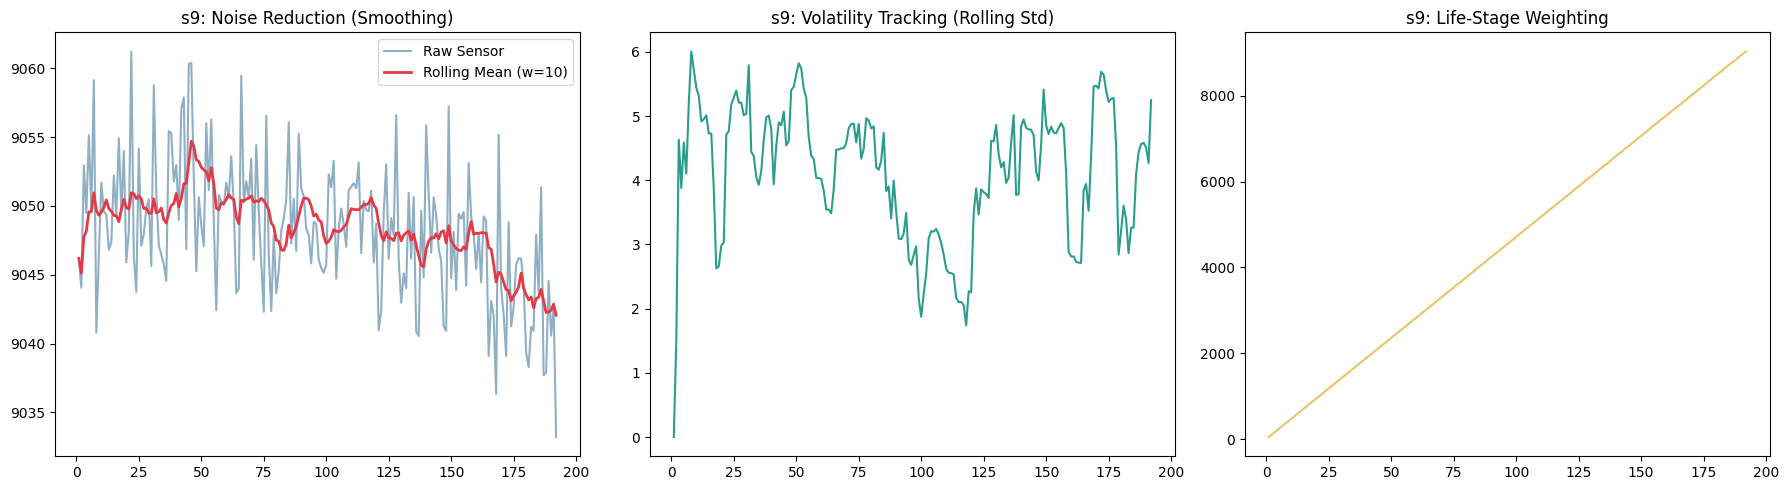

In [7]:
# Visualizing the impact of feature engineering on sensor s9 for a sample engine unit
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sample_eng = 1
sub = df[df['unit_id'] == sample_eng]

# Plotting Raw vs Rolling Mean
axes[0].plot(sub['cycle'], sub['s9'], label='Raw Sensor', color='#457b9d', alpha=0.6)
axes[0].plot(sub['cycle'], sub['s9_roll_mean_10'], label='Rolling Mean (w=10)', color='#e63946', linewidth=2)
axes[0].set_title('s9: Noise Reduction (Smoothing)'); axes[0].legend()

# Plotting Rolling Standard Deviation
axes[1].plot(sub['cycle'], sub['s9_roll_std_10'], color='#2a9d8f')
axes[1].set_title('s9: Volatility Tracking (Rolling Std)')

# Plotting Cycle-Normalized Trends
axes[2].plot(sub['cycle'], sub['s9_cycle_norm'], color='#e9c46a')
axes[2].set_title('s9: Life-Stage Weighting')

plt.tight_layout()
plt.savefig('../results/feature_engineering_preview.png', dpi=150)
plt.show()

In [8]:
# Exporting the final engineered feature set for model training
df.to_csv('../data/processed/FD001_features.csv', index=False)
print(f"Engineered dataset saved successfully. Final shape: {df.shape}")

Engineered dataset saved successfully. Final shape: (20631, 89)
